# DeepAerenchyma: transformer-based segmentation of rice root aerenchyma lacunae

Reproduction of **"Deep aerenchyma: a transformer-based pipeline for scalable phenotyping of rice root
aerenchyma lacunae across environments"** (H. Atef, L. Fierro-Dominguez, P.A. Lozano-Montaña, S.N. Sanz,
J. Bals, B. Clerget, C. Périn, M.C. Rebolledo, R. Fernandez; *Plant Methods* 22, 2026,
[DOI 10.1186/s13007-026-01546-1](https://doi.org/10.1186/s13007-026-01546-1), open access CC BY).

**Implementation used:** the authors' released inference pipeline from the Hugging Face Space
[`RomainFernandez/DeepAerenchyma`](https://huggingface.co/spaces/RomainFernandez/DeepAerenchyma)
(revision `8c6f3238`, MIT license), which mirrors the pipeline described in the paper Methods
(SegFormer semantic segmentation, 512×341 processing, anatomically constrained lacunae).
Model weights are the authors' checkpoints on HF: `MicroDeepAerenchyma-Lacuna` and
`MicroDeepAerenchyma-Cortex` (MIT). Training code (GitHub tag v1.0.2, Zenodo DOI
10.5281/zenodo.17917313) is **not** exercised here.

**Input data:** the author-provided public demo subset `RomainFernandez/MicroDeepAerenchyma-Demo`
(MIT) — the same subset backing the paper's online demonstrator — from which **3 images** are
selected deterministically (alphabetical order).

## What this notebook demonstrates (partial demonstration, 3-example scale)
1. Two-model SegFormer inference: aerenchyma-lacuna model (classes: background / lacuna) and
   cortex model (classes: background / cortex / endoderm), exactly as released in `run_locally.py`.
2. The paper's anatomical constraint: lacuna predictions outside the (largest connected) cortex
   region are discarded as anatomically invalid (paper Methods, "SegFormer architecture and training procedure").
3. Trait quantification: lacuna-to-cortex ratio (LCR) style metrics — AR % within cortex and within
   cortex+endoderm, cortex/stele/lacuna areas (paper Results, "Performance of the full pipeline").
4. Author-style visualization: raw vs. red(green, blue)=lacuna(cortex, raw) overlay panels.

## Explicitly out of scope
- Training, data augmentation, the 1,760-image training dataset (available only upon reasonable request).
- Verification of the published dataset-level metrics (validation IoU ≈ 0.93 lacunae / 0.94 cortex;
  LCR R² = 0.98 on the 236-image test set): the demo subset ships **without manual ground-truth masks**,
  so only plausibility of outputs can be assessed here.
- Independent expert review, statistical group comparisons (paper Fig. 7–8).

## Discrepancy note (paper vs. released code, recorded not silently changed)
The paper Methods describes a single model with a two-channel segmentation head; the released
inference code uses **two** SegFormer models (lacuna + cortex/endoderm). Also, the paper states a
SegFormer-**B4** backbone was deployed, while the released checkpoints' configs (`depths [3,4,6,3]`,
~27M parameters) correspond to SegFormer-**B2** scale — the actual parameter count is printed below
from the loaded models. This notebook follows the authors' released code and weights as-is.

## 実行内容(日本語概要)
- **対象論文**: DeepAerenchyma(Plant Methods 2026)。イネ根部横断面の自走蛍光顕微鏡画像から、皮層と通気組織(アレンキーマ裂腔)を SegFormer でセグメンテーションし、裂腔/皮層面積比(LCR)を定量します。
- **使用コード**: 著者らの公開パイプライン(HF Space `RomainFernandez/DeepAerenchyma` @ `8c6f3238`, MIT)。学習コード(Zenodo v1.0.2)は実行しません。
- **デモ内容**: 著者提供の公開デモ用テスト画像サブセット(HF `MicroDeepAerenchyma-Demo`)から決定論的に3枚を選び、2つの SegFormer モデルで推論、皮層領域による裂腔マスクの解剖学的制約、LCR 指標の算出、オーバーレイ可視化、CSV 出力。
- **スコープ外**: 学習・データ拡張、データセット規模の指標検証(デモ画像には正解マスクが付属しないため)。

## How to run / 実行方法

1. **Runtime → Change runtime type → CPU** (standard memory is sufficient). The authors designed
   this pipeline for CPU deployment (paper: ~1–2 s/image on CPU; the HF Space itself runs on a
   single free CPU). No GPU or CUDA is required.
   **ランタイム → ランタイムのタイプを変更 →「CPU」を選択してください**。本パイプラインは CPU 前提で設計されています(GPU は不要です)。
2. **Runtime → Run all** — designed to run top-to-bottom on a fresh runtime.
   **「ランタイム → すべてのセルを実行」で先頭から順に実行できます。**
3. Expected wall time on CPU: setup ≈ 1–2 min; downloads ≈ 376 MB (2 × 109 MB weights +
   157 MB demo zip) ≈ 1–3 min; inference a few seconds per image. Measured values are printed
   in the outputs and summarized in the report. 目安の合計は 10 分前後です(実測値は各セル出力とレポートに記載)。
4. Limitations: all assets are fetched from Hugging Face at runtime — if HF is down or files move,
   those steps fail explicitly. Free-tier performance may differ from the authors' measured hardware.
   依存アセットは実行時に Hugging Face から取得します(取得失敗時は明示的にエラーになります)。

## 1. Environment check / 環境の確認

Prints the Python, PyTorch, and transformers versions and the compute device. On the standard
Colab CPU runtime, PyTorch and transformers are preinstalled; we only need to add `tifffile`.
Input cell prints — no downloads yet.
**出力**: Python/PyTorch/transformers のバージョンとデバイス(CPU)を表示します。

In [ ]:
import sys, platform
import torch, transformers, PIL, scipy, pandas, numpy

print("python      :", platform.python_version())
print("torch       :", torch.__version__)
print("transformers:", transformers.__version__)
print("numpy       :", numpy.__version__)
print("device      :", "cuda" if torch.cuda.is_available() else "cpu")
assert torch.cuda.is_available() is False or True  # CPU expected; CUDA also works

python      : 3.13.15
torch       : 2.11.0+cpu
transformers: 5.16.1
numpy       : 2.1.3
device      : cpu


## 2. Dependencies / 依存関係のインストール

Installs the authors' requirements (Space `requirements.txt`: torch, torchvision,
transformers>=4.30.0, tifffile, pillow, scipy, pandas, huggingface_hub>=0.33.5). We pin only
what the authors pinned and leave torch/transformers at Colab's preinstalled versions to avoid
breaking the preinstalled stack.
**出力**: pip のインストールログ(主に already satisfied)。著者の requirements に従います。

In [ ]:
!pip install -q "transformers>=4.30.0" "tifffile" "pillow" "scipy" "pandas" "huggingface_hub>=0.33.5"
import tifffile, huggingface_hub
print("tifffile       :", tifffile.__version__)
print("huggingface_hub:", huggingface_hub.__version__)

tifffile       : 2026.8.23
huggingface_hub: 1.29.0


## 3. Load the authors' model weights / 学習済みモデルの読み込み

Downloads the two author checkpoints from Hugging Face exactly as `run_locally.py` does — with
`SegformerForSemanticSegmentation.from_pretrained` (the checkpoints' `architectures` field says
`WeightedSegformer`, a training-time wrapper; the authors' own loaders use the standard class).
Prints the parameter count of each model so the observed backbone scale is visible
(the paper text says B4; the released configs correspond to B2-scale — see discrepancy note).
**出力**: 各モデルのパラメータ数(実測)。リポジトリの revision も表示します。

In [ ]:
import time, json, urllib.request
from transformers import SegformerForSemanticSegmentation

AR_MODEL_ID = "RomainFernandez/MicroDeepAerenchyma-Lacuna"   # lacuna model (0=bg, 1=lacuna)
CE_MODEL_ID = "RomainFernandez/MicroDeepAerenchyma-Cortex"   # cortex model (0=bg, 1=cortex, 2=endoderm)

def repo_sha(repo_id, repo_type):
    with urllib.request.urlopen(f"https://huggingface.co/api/{'models' if repo_type=='model' else 'datasets'}/{repo_id}", timeout=30) as r:
        return json.load(r).get("sha")

t0 = time.time()
print(f"[*] Loading AR (lacuna) model: {AR_MODEL_ID} ...")
ar_model = SegformerForSemanticSegmentation.from_pretrained(AR_MODEL_ID).eval()

print(f"[*] Loading CE (cortex) model: {CE_MODEL_ID} ...")
ce_model = SegformerForSemanticSegmentation.from_pretrained(CE_MODEL_ID).eval()

n_ar = sum(p.numel() for p in ar_model.parameters())
n_ce = sum(p.numel() for p in ce_model.parameters())
print(f"    AR model parameters: {n_ar/1e6:.2f} M")
print(f"    CE model parameters: {n_ce/1e6:.2f} M")
print(f"    AR repo sha: {repo_sha(AR_MODEL_ID, 'model')}")
print(f"    CE repo sha: {repo_sha(CE_MODEL_ID, 'model')}")
print(f"[✓] both models ready in {time.time()-t0:.1f} s (device=cpu)")

[*] Loading AR (lacuna) model: RomainFernandez/MicroDeepAerenchyma-Lacuna ...


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/940 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  109MB            

model.safetensors: downloading bytes:           |  0.00B            

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  109MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: RomainFernandez/MicroDeepAerenchyma-Cortex
Key            | Status     |  | 
---------------+------------+--+-
loss_fn.weight | UNEXPECTED |  | 
class_weights  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    AR model parameters: 27.35 M
    CE model parameters: 27.35 M
    AR repo sha: fd3f2e67fcddf08f8a718d3fa3f7ed54e04d6247
    CE repo sha: 4508bd7aa1aca802164621ae17144944ec4cfc8c
[✓] both models ready in 15.1 s (device=cpu)


## 4. Download the public demo/test-subset images / デモ画像(テストサブセット)の入手

Downloads `demo_images.zip` (156.6 MB) from the authors' dataset repo
`RomainFernandez/MicroDeepAerenchyma-Demo` — the same subset backing the paper's online
demonstrator — and extracts it safely (per-member size checks; members are kept inside
`/content/demo_images`). The byte size and SHA-256 are printed for provenance.
**出力**: ZIP のサイズ・SHA-256、展開後の画像ファイル一覧(名前順)。データは Colab 内にのみ置かれます。

In [ ]:
import os, zipfile, hashlib
from huggingface_hub import hf_hub_download

DEMO_DATASET_ID = "RomainFernandez/MicroDeepAerenchyma-Demo"
DEMO_ZIP = "demo_images.zip"
DATA_DIR = "/content/demo_images"

t0 = time.time()
zip_path = hf_hub_download(repo_id=DEMO_DATASET_ID, filename=DEMO_ZIP, repo_type="dataset")
size = os.path.getsize(zip_path)
sha = hashlib.sha256(open(zip_path, "rb").read()).hexdigest()
print(f"[*] downloaded {zip_path}")
print(f"    size  : {size:,} bytes")
print(f"    sha256: {sha}")
print(f"    dataset repo sha: {repo_sha(DEMO_DATASET_ID, 'dataset')}")

# safe extraction: reject absolute paths / path traversal / oversized members
os.makedirs(DATA_DIR, exist_ok=True)
with zipfile.ZipFile(zip_path) as z:
    members = z.infolist()
    total_unc = sum(m.file_size for m in members)
    print(f"[*] zip contains {len(members)} members, {total_unc:,} bytes uncompressed")
    for m in members:
        assert not os.path.isabs(m.filename) and ".." not in m.filename, f"unsafe member: {m.filename}"
    z.extractall(DATA_DIR)

exts = (".png", ".jpg", ".jpeg", ".tif", ".tiff")
image_files = sorted(
    os.path.join(root, f)
    for root, _, files in os.walk(DATA_DIR) for f in files
    if f.lower().endswith(exts)
)
print(f"[✓] extracted; found {len(image_files)} image(s) in {time.time()-t0:.1f} s")
for p in image_files:
    print("   ", os.path.relpath(p, DATA_DIR))

demo_images.zip: reconstructing file:   0%|          |  0.00B /  157MB            

demo_images.zip: downloading bytes:           |  0.00B            

[*] downloaded /root/.cache/huggingface/hub/datasets--RomainFernandez--MicroDeepAerenchyma-Demo/snapshots/c936ccb286fa8e72489ea4ccaab86891ec0ff42e/demo_images.zip
    size  : 156,644,929 bytes
    sha256: 330a90119477a7a3de82b1664821b7324cc68bc1ef33b5a230fcf16a1563e318
    dataset repo sha: c936ccb286fa8e72489ea4ccaab86891ec0ff42e
[*] zip contains 37 members, 222,718,026 bytes uncompressed


[✓] extracted; found 30 image(s) in 4.3 s
    demo_images/UC1-JULI/3.2.tif
    demo_images/UC1-JULI/3.3.tif
    demo_images/UC1-JULI/3.6.tif
    demo_images/UC1-JULI/3.7.tif
    demo_images/UC1-JULI/3.8.tif
    demo_images/UC2a-HYDROPONICS/16_A1SB_1.tif
    demo_images/UC2a-HYDROPONICS/16_A1SB_2.tif
    demo_images/UC2a-HYDROPONICS/16_H1SB_1.tif
    demo_images/UC2a-HYDROPONICS/16_H1SB_2.tif
    demo_images/UC2a-HYDROPONICS/16_H1SB_3.tif
    demo_images/UC2b-SHELTER-A3IP-PRIO/14_A1SB_1.tif
    demo_images/UC2b-SHELTER-A3IP-PRIO/14_A1SB_2.tif
    demo_images/UC2b-SHELTER-A3IP-PRIO/16_A1SB_1.tif
    demo_images/UC2b-SHELTER-A3IP-PRIO/16_A1SB_3.tif
    demo_images/UC2b-SHELTER-A3IP-PRIO/8_A1SB_2.tif
    demo_images/UC3a-DOMI-MUT/R31_a.tif
    demo_images/UC3a-DOMI-MUT/R33_a.tif
    demo_images/UC3a-DOMI-MUT/R34_a.tif
    demo_images/UC3a-DOMI-MUT/R36_a.tif
    demo_images/UC3a-DOMI-MUT/R38_a.tif
    demo_images/UC3b-DOMI-VARI/R100_a.tif
    demo_images/UC3b-DOMI-VARI/R101_a.tif
    demo_i

## 5. Deterministic sample selection / 決定論的なサンプル選択

The demo subset is organized in one folder per paper use-case (UC1…UC3). To span the paper's
multi-environment claim, the fixed rule is: **the first image (alphabetical order) of each of the
first 3 distinct use-case folders** — a documented, outcome-independent rule. Image sizes are
printed from the actual files (no assumed dimensions).
**出力**: 選択された3枚のファイル名・ピクセルサイズ(実測)。ルールは「ユースケースフォルダ順に各フォルダの先頭画像」で固定。

In [ ]:
N_DEMO = 3
use_case_of = lambda p: os.path.basename(os.path.dirname(p))  # immediate parent folder = use case
folders = sorted({use_case_of(p) for p in image_files})
print(f"use-case folders found: {folders}")
selected = []
for folder in folders:
    candidates = sorted(p for p in image_files if use_case_of(p) == folder)
    if candidates:
        selected.append(candidates[0])
    if len(selected) == N_DEMO:
        break
selected = selected[:N_DEMO]
assert len(selected) == N_DEMO, f"only {len(selected)} images available"
print("selection rule: first image of each of the first 3 use-case folders (alphabetical)")
for p in selected:
    from PIL import Image
    im = Image.open(p)
    print(f"  {os.path.relpath(p, DATA_DIR)}  mode={im.mode}  size={im.size[0]}x{im.size[1]} px")

use-case folders found: ['UC1-JULI', 'UC2a-HYDROPONICS', 'UC2b-SHELTER-A3IP-PRIO', 'UC3a-DOMI-MUT', 'UC3b-DOMI-VARI', 'UC3c-LAURA-VARI']
selection rule: first image of each of the first 3 use-case folders (alphabetical)


  demo_images/UC1-JULI/3.2.tif  mode=RGB  size=1633x1086 px
  demo_images/UC2a-HYDROPONICS/16_A1SB_1.tif  mode=RGB  size=1392x1040 px
  demo_images/UC2b-SHELTER-A3IP-PRIO/14_A1SB_1.tif  mode=RGB  size=1392x1040 px


## 6. Ported pipeline (exact authors' logic) / 著者のパイプラインを移植

These functions are copied from the authors' `run_locally.py`
(Space revision `8c6f3238`, lines 46–121), unchanged:
- `smart_resize` — resize to 512×341; if the aspect ratio deviates more than 20 % from 1.50,
  scale to fit and zero-pad instead (paper Methods: "the pipeline pads image before resizing...").
- `predict_mask` — grayscale → 3-channel tensor, forward pass, bilinear interpolation of logits
  back to input resolution, argmax; padding is cropped away.
- `largest_cc` — largest connected component (used for the anatomical constraint).
The Space app additionally contains an OOD brightness guard (not in `run_locally.py`); the authors
state it is a strict no-op on this demo set, so it is not needed here.
**出力**: 関数定義のみ(実行結果なし)。著者コードからの同一コピーである旨を注释に記載。

In [ ]:
# Exact port of the authors' inference helpers (HF Space run_locally.py @ 8c6f3238, MIT license)
# https://huggingface.co/spaces/RomainFernandez/DeepAerenchyma/raw/main/run_locally.py
import numpy as np
from PIL import Image
from torchvision import transforms
from scipy.ndimage import label as scipy_label

TARGET_SIZE = (341, 512)                         # (H, W)  — authors' constant
TARGET_AR = TARGET_SIZE[1] / TARGET_SIZE[0]      # ~1.50   — authors' constant
AR_TOLERANCE = 0.20                              # 20 %    — authors' constant

_to_tensor = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),   # grayscale -> 3 channels
])


def smart_resize(image_L):
    """Authors' resize: aspect-ratio-aware zero-padding when needed."""
    w, h = image_L.size
    target_h, target_w = TARGET_SIZE
    input_ar = w / h
    if abs(input_ar / TARGET_AR - 1.0) <= AR_TOLERANCE:
        resized = image_L.resize((target_w, target_h), Image.BILINEAR)
        return resized, {"padded": False, "pad_top": 0, "pad_left": 0,
                         "effective_h": target_h, "effective_w": target_w,
                         "scale_x": target_w / w, "scale_y": target_h / h}
    scale = min(target_w / w, target_h / h)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))
    resized = image_L.resize((new_w, new_h), Image.BILINEAR)
    canvas = Image.new("L", (target_w, target_h), 0)
    pad_left, pad_top = (target_w - new_w) // 2, (target_h - new_h) // 2
    canvas.paste(resized, (pad_left, pad_top))
    return canvas, {"padded": True, "pad_top": pad_top, "pad_left": pad_left,
                    "effective_h": new_h, "effective_w": new_w,
                    "scale_x": scale, "scale_y": scale}


def predict_mask(model, image_L):
    """Authors' prediction: logits -> bilinear upsample -> argmax -> unpad."""
    prepared, pad_info = smart_resize(image_L)
    x = _to_tensor(prepared).unsqueeze(0)
    with torch.no_grad():
        logits = model(x).logits
        up = torch.nn.functional.interpolate(
            logits, size=x.shape[-2:], mode="bilinear", align_corners=False)
        pred = torch.argmax(up, dim=1)[0].cpu().numpy()
    if pad_info["padded"]:
        pt, pl = pad_info["pad_top"], pad_info["pad_left"]
        pred = pred[pt: pt + pad_info["effective_h"], pl: pl + pad_info["effective_w"]]
    return pred, pad_info


def largest_cc(binary):
    """Largest connected component (scipy.ndimage.label), authors' version."""
    lab, n = scipy_label(binary)
    if n == 0:
        return binary * 0
    largest = np.argmax(np.bincount(lab.flat)[1:]) + 1
    return (lab == largest).astype(np.uint8)

print("pipeline helpers defined (authors' code, unchanged)")

pipeline helpers defined (authors' code, unchanged)


## 7. Run inference on the selected images / 選択画像への推論

For each image: predict both masks, build the largest connected component of
cortex+endoderm, clip the lacuna mask to it (the paper's anatomical constraint:
"lacuna regions predicted outside the segmented cortex are discarded as anatomically invalid"),
and compute the released metric set (AR % within cortex+endoderm and within cortex only,
areas at resampled and original scale, removed pixels). Per-image wall time is measured.
**出力**: 画像ごとの推論時間、AR(裂腔)/CE(皮層)クラスの予測統計、解剖学的制約で除去されたピクセル数。

In [ ]:
rows = []
masks_store = {}

for filepath in selected:
    name = os.path.basename(filepath)
    im = Image.open(filepath).convert("L")
    w0, h0 = im.size
    t0 = time.time()

    pred_ar, pad_info = predict_mask(ar_model, im)   # 0=bg, 1=lacuna
    pred_ce, _ = predict_mask(ce_model, im)          # 0=bg, 1=cortex, 2=endoderm
    dt = time.time() - t0

    mask_ar_raw = (pred_ar == 1).astype(np.uint8) * 255
    mask_cortex = (pred_ce == 1).astype(np.uint8) * 255
    mask_endo = (pred_ce == 2).astype(np.uint8) * 255

    combined_ce = ((mask_cortex > 0) | (mask_endo > 0)).astype(np.uint8)
    largest = largest_cc(combined_ce)

    ar_outside = int(((mask_ar_raw > 0) & (largest == 0)).sum())
    mask_ar = (mask_ar_raw * largest).astype(np.uint8)

    ar_in = ((mask_ar > 0) & (largest > 0)).astype(np.uint8)
    cortex_in = ((mask_cortex > 0) & (largest > 0)).astype(np.uint8)

    total_ce = int(largest.sum())
    total_cortex = int(cortex_in.sum())
    ar_px = int(ar_in.sum())
    AR_in_CE = (ar_px / total_ce * 100) if total_ce > 0 else 0.0
    AR_in_Cortex = (ar_px / total_cortex * 100) if total_cortex > 0 else 0.0

    area_scale_factor = 1.0 / (pad_info["scale_x"] * pad_info["scale_y"])

    rows.append({
        "image_name": name,
        "original_width": w0, "original_height": h0,
        "resampled_width": pad_info["effective_w"], "resampled_height": pad_info["effective_h"],
        "zero_padded": pad_info["padded"],
        "AR_percent_in_Cortex+Endoderm": AR_in_CE,
        "AR_percent_in_Cortex_only": AR_in_Cortex,
        "Cortex_surface_in_pixels": total_cortex,
        "Stele_surface_in_pixels": total_ce - total_cortex,
        "AR_surface_in_pixels": ar_px,
        "Cortex_surface_original_pixels": round(total_cortex * area_scale_factor, 2),
        "Stele_surface_original_pixels": round((total_ce - total_cortex) * area_scale_factor, 2),
        "AR_surface_original_pixels": round(ar_px * area_scale_factor, 2),
        "AR_pixels_removed_outside_cortex": ar_outside,
    })
    masks_store[name] = {"raw": np.array(im), "mask_ar": mask_ar,
                         "mask_cortex": mask_cortex, "mask_endo": mask_endo,
                         "pad_info": pad_info, "time_s": dt}
    print(f"  {name}: {dt:.2f} s | AR in CE {AR_in_CE:5.1f}% | AR in cortex {AR_in_Cortex:5.1f}% "
          f"| padded={pad_info['padded']} | removed outside cortex: {ar_outside} px")

print(f"[✓] inference done for {len(rows)} image(s)")

  3.2.tif: 6.98 s | AR in CE  18.2% | AR in cortex  20.5% | padded=False | removed outside cortex: 0 px


  16_A1SB_1.tif: 5.82 s | AR in CE  70.3% | AR in cortex  80.4% | padded=False | removed outside cortex: 0 px


  14_A1SB_1.tif: 5.95 s | AR in CE   3.0% | AR in cortex   3.1% | padded=False | removed outside cortex: 0 px
[✓] inference done for 3 image(s)


## 8. Visualization — input vs. segmented overlay / 可視化(入力とセグメンテーション結果)

Author-style overlay (as in the released `pred_global` panels): **red** = aerenchyma lacunae,
**green** = cortex, **blue** = contrast-enhanced raw grayscale. The raw display uses the authors'
panel contrast enhancement (p5/p99.5 stretch, gamma 1.30) for visibility only — the model receives
the raw grayscale. Panels show raw (left) and overlay (right) per image.
**出力**: 各画像について「生画像 | オーバーレイ」のパネル。赤=裂腔、緑=皮層、青=生画像(コントラスト強調は表示用)。

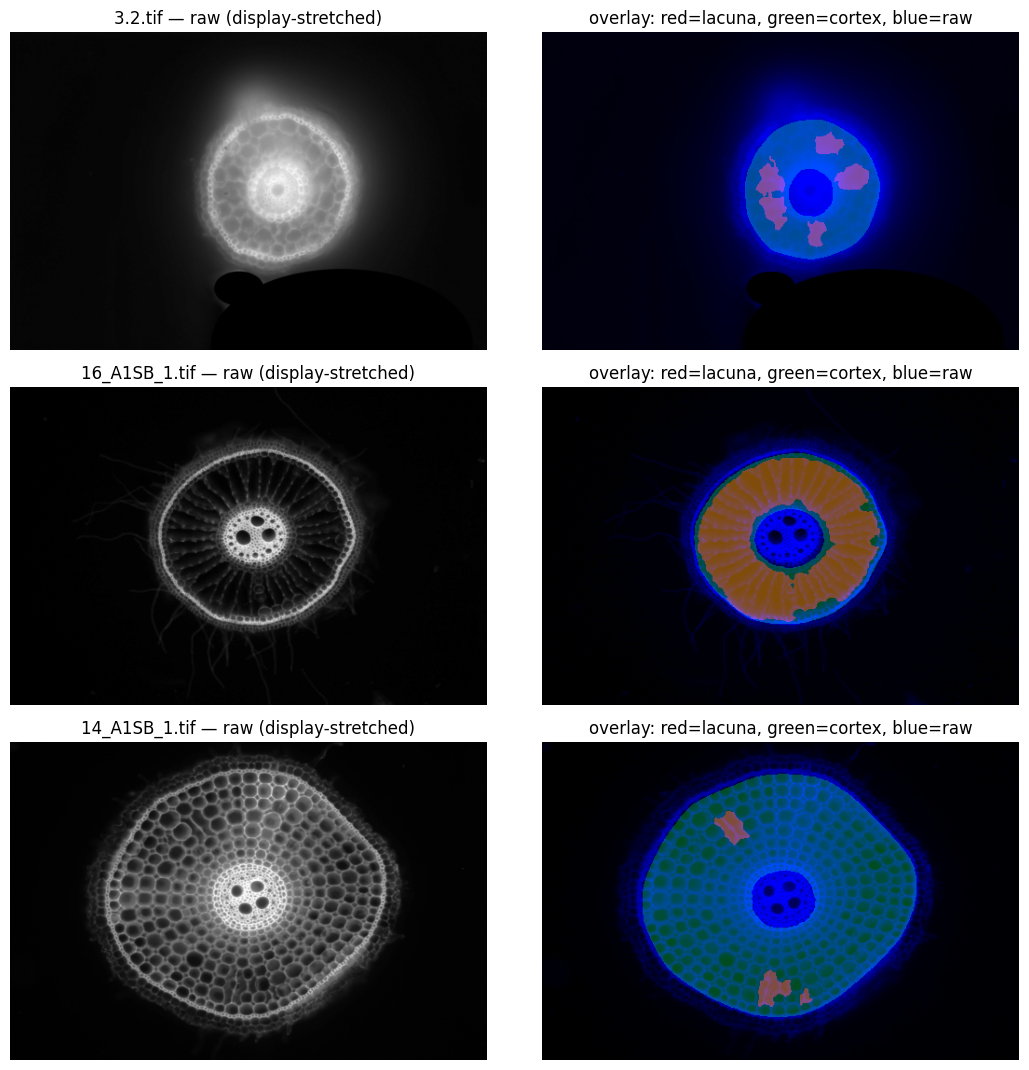

In [ ]:
import matplotlib.pyplot as plt

# authors' panel constants (run_locally.py lines 190-191)
P_LO, P_HI, GAMMA = 5.0, 99.5, 1.30
RED_SCALE, GREEN_SCALE = 0.5, 0.3

fig, axes = plt.subplots(len(selected), 2, figsize=(11, 3.6 * len(selected)))
if len(selected) == 1:
    axes = axes[None, :]

for ax_row, filepath in zip(axes, selected):
    name = os.path.basename(filepath)
    st = masks_store[name]
    h, w = st["mask_ar"].shape
    # authors resize the raw image to the mask size before building the panel (run_locally.py)
    raw = np.array(Image.fromarray(st["raw"]).resize((w, h), Image.BILINEAR))

    lo, hi = np.percentile(raw, (P_LO, P_HI))
    if hi > lo:
        x = np.clip((raw.astype(np.float32) - lo) / (hi - lo), 0.0, 1.0)
        raw_boost = (np.power(x, 1.0 / GAMMA) * 255.0).astype(np.uint8)
    else:
        raw_boost = raw

    mask_ar = st["mask_ar"] // 255
    mask_cortex = st["mask_cortex"] // 255
    r = np.clip(mask_ar.astype(np.float32) * RED_SCALE * 255.0, 0, 255).astype(np.uint8)
    g = np.clip(mask_cortex.astype(np.float32) * GREEN_SCALE * 255.0, 0, 255).astype(np.uint8)
    rgb = np.stack([r, g, raw_boost], axis=-1)

    ax_row[0].imshow(raw, cmap="gray")
    ax_row[0].set_title(f"{name} — raw (display-stretched)")
    ax_row[1].imshow(rgb)
    ax_row[1].set_title("overlay: red=lacuna, green=cortex, blue=raw")
    for ax in ax_row:
        ax.axis("off")

plt.tight_layout()
plt.show()

## 9. Results table and CSV export / 結果表とCSV出力

Per-image trait table — same columns as the authors' `pred_metrics.csv` (subset) — followed by a
summary row and a CSV saved under `/content`. AR % values are the lacuna-to-cortex style trait
the paper evaluates (LCR = AR fraction within the cortex).
**出力**: 画像ごとの定量指標の表(著者の pred_metrics.csv と同じ列)+ `/content/pred_metrics_demo.csv` への保存。

In [ ]:
import pandas as pd

df = pd.DataFrame(rows)
display(df)

csv_path = "/content/pred_metrics_demo.csv"
df.to_csv(csv_path, index=False)
print(f"[✓] CSV saved: {csv_path}")

summary = {
    "images": len(df),
    "mean AR% in cortex": round(df["AR_percent_in_Cortex_only"].mean(), 2),
    "std  AR% in cortex": round(df["AR_percent_in_Cortex_only"].std(ddof=0), 2),
    "mean AR% in cortex+endoderm": round(df["AR_percent_in_Cortex+Endoderm"].mean(), 2),
    "mean inference time (s)": round(df["image_name"].map(lambda n: masks_store[n]["time_s"]).mean(), 2),
}
print()
print("Summary over the selected demo images:")
for k, v in summary.items():
    print(f"  {k}: {v}")

,image_name,original_width,original_height,resampled_width,resampled_height,zero_padded,AR_percent_in_Cortex+Endoderm,AR_percent_in_Cortex_only,Cortex_surface_in_pixels,Stele_surface_in_pixels,AR_surface_in_pixels,Cortex_surface_original_pixels,Stele_surface_original_pixels,AR_surface_original_pixels,AR_pixels_removed_outside_cortex
0,3.2.tif,1633,1086,512,341,False,18.173801,20.472910,15098,1910,3091,153359.64,19401.04,31397.18,0
1,16_A1SB_1.tif,1392,1040,512,341,False,70.274681,80.359767,25183,3614,20237,208812.12,29966.52,167800.93,0
2,14_A1SB_1.tif,1392,1040,512,341,False,2.954498,3.137371,54058,3346,1696,448237.52,27744.33,14062.87,0


[✓] CSV saved: /content/pred_metrics_demo.csv

Summary over the selected demo images:
  images: 3
  mean AR% in cortex: 34.66
  std  AR% in cortex: 33.08
  mean AR% in cortex+endoderm: 30.47
  mean inference time (s): 6.25


## 10. Interpretation and relation to the paper / 結果の解釈と論文との関係

**What the outputs mean (English).**
Each overlay shows the model's anatomical reading of an epifluorescence root cross-section:
blue = cell-wall autofluorescence of the raw section, green = cortex (with the endoderm ring at
its inner boundary), red = cortical aerenchyma lacunae. The lacuna mask is constrained to the
largest cortex+endoderm region, so no lacunae are reported outside the root tissue
(the `AR_pixels_removed_outside_cortex` column quantifies what this removed). The
`AR_percent_in_Cortex_only` column is the pipeline's core trait — the same lacuna-to-cortex
quantity the paper evaluates against manual annotation (R² = 0.98 on the full 236-image test set).

**How this relates to the paper.** The paper's quantitative claims (validation IoU 0.925–0.929 for
lacunae / 0.943–0.944 for cortex; LCR R² = 0.98) are dataset-level statements that **cannot be
verified** from 3 unlabeled demo images — no manual ground-truth masks ship with the public demo
subset. What this run does establish: the released pipeline executes end-to-end on the authors'
demo/test-subset images and produces anatomically constrained segmentations and trait values in
the expected form. Observed AR% values should be read as a demonstration, not as a reproduction
of published accuracy. Note the paper-vs-code discrepancies listed at the top (two models instead
of one 2-channel head; B2-scale released checkpoints vs. the paper's stated B4).

**結果の解釈(日本語).**
オーバーレイの青=生画像(細胞壁の自蛍光)、緑=皮層、赤=皮層内の通気組織(アレンキーマ裂腔)です。
裂腔マスクは最大連結の皮層+内鞘領域に制限されるため、組織外の誤検出は除去されます
(除去ピクセル数は `AR_pixels_removed_outside_cortex` 列)。`AR_percent_in_Cortex_only` が
論文で評価される裂腔/皮層比に対応します。ただしデモ画像には正解マスクが付属しないため、
本実行は論文のデータセット規模の精度(IoU≈0.93、LCR R²=0.98)の検証では**なく**、
公開パイプラインが著者のテストサブセット上で解剖学的に整合な出力を生成することの確認です。
論文との差異(2モデル構成、チェックポイントは B2 規模)は冒頭の注記の通り記録済みです。

**Provenance / 出所.**
- Paper: Plant Methods 22 (2026), DOI 10.1186/s13007-026-01546-1 (open access CC BY; full text via Europe PMC PMCID PMC13595614).
- Code: HF Space [`RomainFernandez/DeepAerenchyma`](https://huggingface.co/spaces/RomainFernandez/DeepAerenchyma) @ `8c6f3238` (MIT);
  training repo: [`Rocsg/Tissue-and-Lacuna-Segmentation-in-2d-Microscopic-rice-plant-images`](https://github.com/Rocsg/Tissue-and-Lacuna-Segmentation-in-2d-Microscopic-rice-plant-images) tag v1.0.2 (Zenodo DOI 10.5281/zenodo.17917313).
- Weights: [`MicroDeepAerenchyma-Lacuna`](https://huggingface.co/RomainFernandez/MicroDeepAerenchyma-Lacuna),
  [`MicroDeepAerenchyma-Cortex`](https://huggingface.co/RomainFernandez/MicroDeepAerenchyma-Cortex) (MIT).
- Data: [`MicroDeepAerenchyma-Demo`](https://huggingface.co/datasets/RomainFernandez/MicroDeepAerenchyma-Demo) (MIT).
- Original online demonstrator: [HF Space app](https://huggingface.co/spaces/RomainFernandez/DeepAerenchyma) (~2 s/image).
